# **<font color='magenta'>Laboratorio 5: EDA  Multivariado </font>**

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
#Renombrar el nombre de las columnas
df = df.rename({'survived': 'Sobreviviente','pclass':'ClasePasaje',
                    'sex':'Sexo','age':'Edad',
                    'sibsp': 'HnsEsposo', 'parch':'PadresHijos',
                    'fare': 'Tarifa','embarked':'Embarcacion',
                    'class': 'Clase','who':'Genero','adult_male':'HombreAdulto',
                    'deck': 'Cubierta', 'embark_town': 'LugarEmbarcacion',
                    'alive': 'Vivo','alone':'Solo'}, axis=1)
#Axis indexa = 1 es para nombre de columnas y el otro indexa = 2
df

,Sobreviviente,ClasePasaje,Sexo,Edad,HnsEsposo,PadresHijos,Tarifa,Embarcacion,Clase,Genero,HombreAdulto,Cubierta,LugarEmbarcacion,Vivo,Solo
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [13]:
#Creamos una tabla cruzada entre el clase y cubierta
#agregar margins: devuelve la suma (el tipo depende de las cols)
pd.crosstab(df['Clase'], df['Cubierta'], margins=True)


Cubierta,A,B,C,D,E,F,G,All
Clase,,,,,,,,
First,15,47,59,29,25,0,0,175
Second,0,0,0,4,4,8,0,16
Third,0,0,0,0,3,5,4,12
All,15,47,59,33,32,13,4,203


In [ ]:
#Para normalizar a % se usa normalize= all
pd.crosstab(df['Clase'], df['Cubierta'], normalize='all', margins=True)

Cubierta,A,B,C,D,E,F,G
Clase,,,,,,,
First,0.073892,0.231527,0.29064,0.142857,0.123153,0.000000,0.000000
Second,0.000000,0.000000,0.00000,0.019704,0.019704,0.039409,0.000000
Third,0.000000,0.000000,0.00000,0.000000,0.014778,0.024631,0.019704


In [16]:
df.select_dtypes(include='number').cov()

,Sobreviviente,ClasePasaje,Edad,HnsEsposo,PadresHijos,Tarifa
Sobreviviente,0.236772,-0.137703,-0.551296,-0.018954,0.032017,6.221787
ClasePasaje,-0.137703,0.699015,-4.496004,0.076599,0.012429,-22.830196
Edad,-0.551296,-4.496004,211.019125,-4.163334,-2.344191,73.849030
HnsEsposo,-0.018954,0.076599,-4.163334,1.216043,0.368739,8.748734
PadresHijos,0.032017,0.012429,-2.344191,0.368739,0.649728,8.661052
Tarifa,6.221787,-22.830196,73.849030,8.748734,8.661052,2469.436846


In [7]:
df.select_dtypes(include='number').corr()

,Sobreviviente,ClasePasaje,Edad,HnsEsposo,PadresHijos,Tarifa
Sobreviviente,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
ClasePasaje,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Edad,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
HnsEsposo,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
PadresHijos,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Tarifa,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [8]:
#Se puede cambiar el tamaño de las figuras
sns.set(rc={"figure.figsize":(10, 8)}) #ancho=10, alto=8

<Axes: xlabel='Clase', ylabel='Edad'>

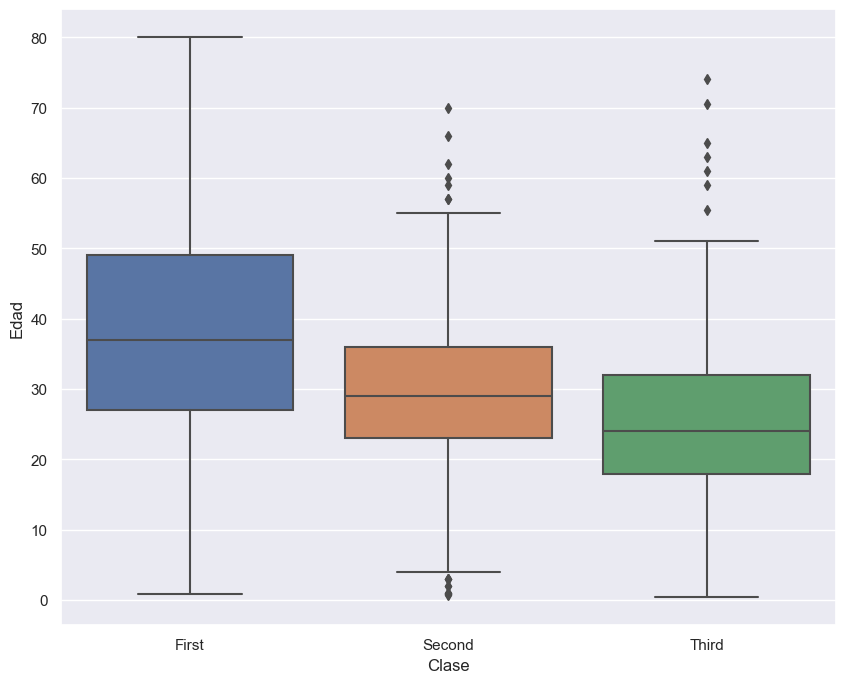

In [11]:
sns.boxplot(x='Clase',y='Edad',data=df)

In [12]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

<Axes: xlabel='Clase', ylabel='Edad'>

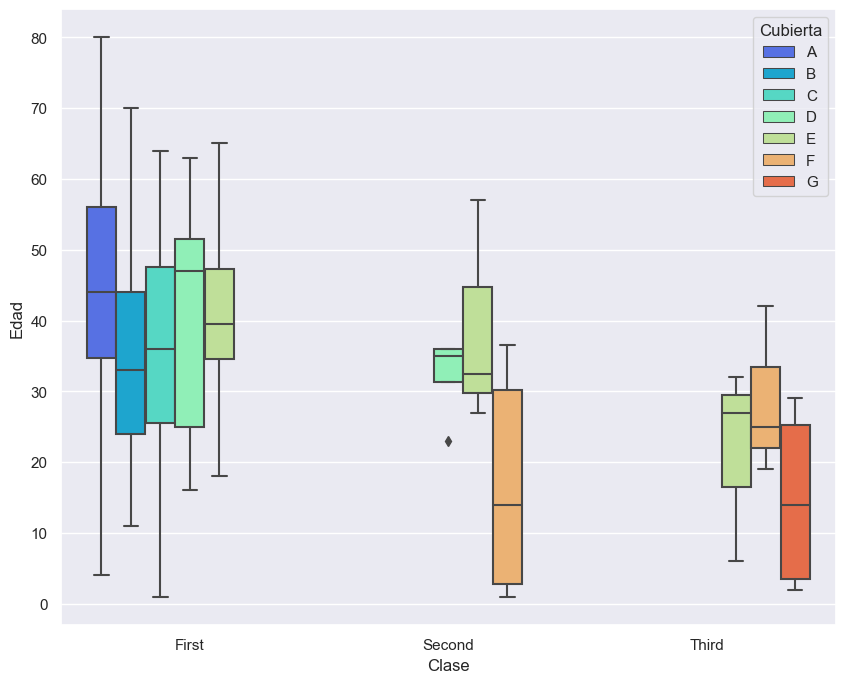

In [13]:
sns.boxplot(x='Clase',y='Edad',data=df, palette='rainbow', hue='Cubierta')

<Axes: xlabel='Edad', ylabel='Count'>

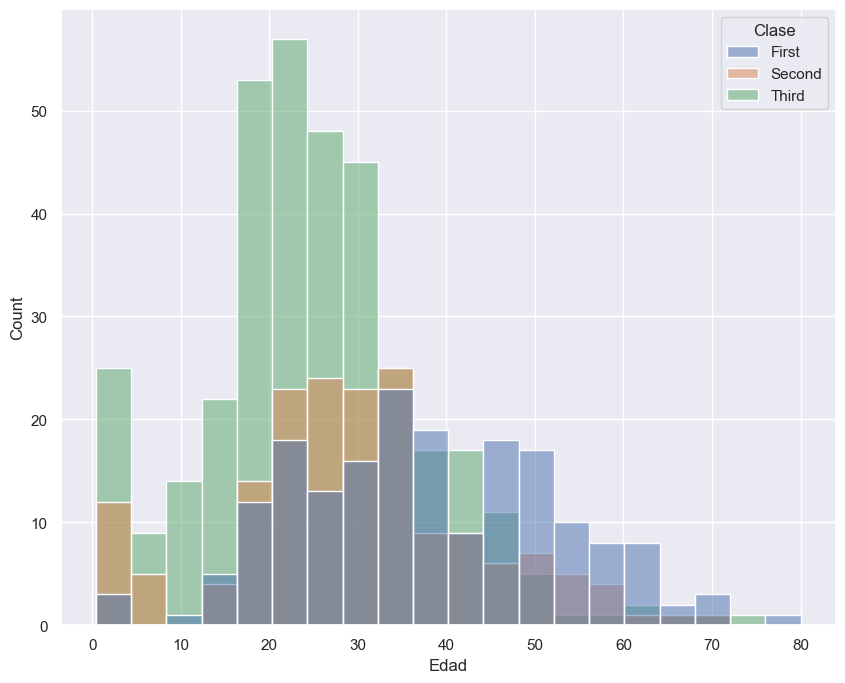

In [14]:
#Histograma
sns.histplot(data=df, x='Edad',hue='Clase', bins=20)

<Axes: xlabel='Clase', ylabel='count'>

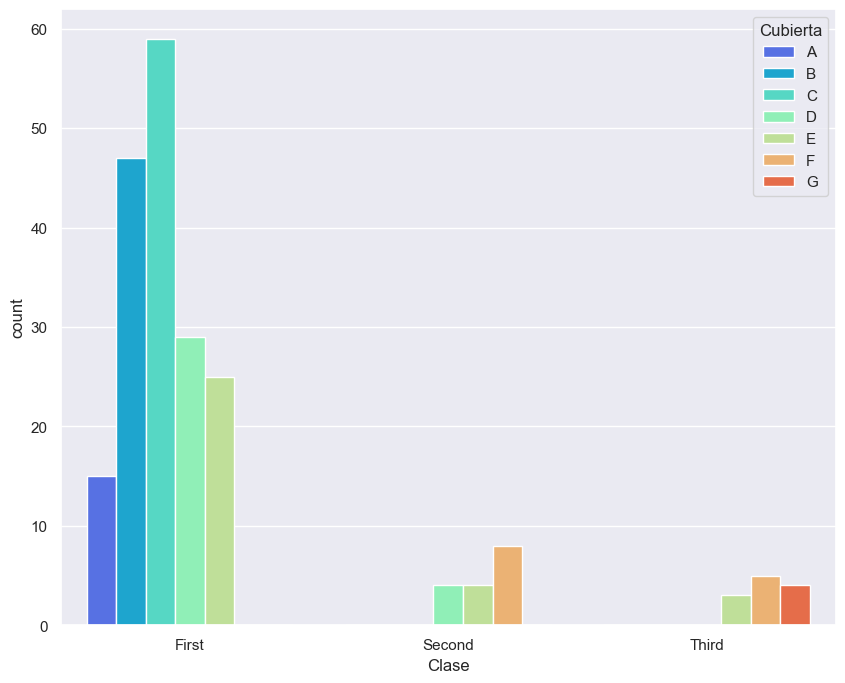

In [15]:
# Grafico para variables categóricas
sns.countplot(x="Clase",data=df,hue='Cubierta', palette='rainbow')

<Axes: xlabel='Clase', ylabel='count'>

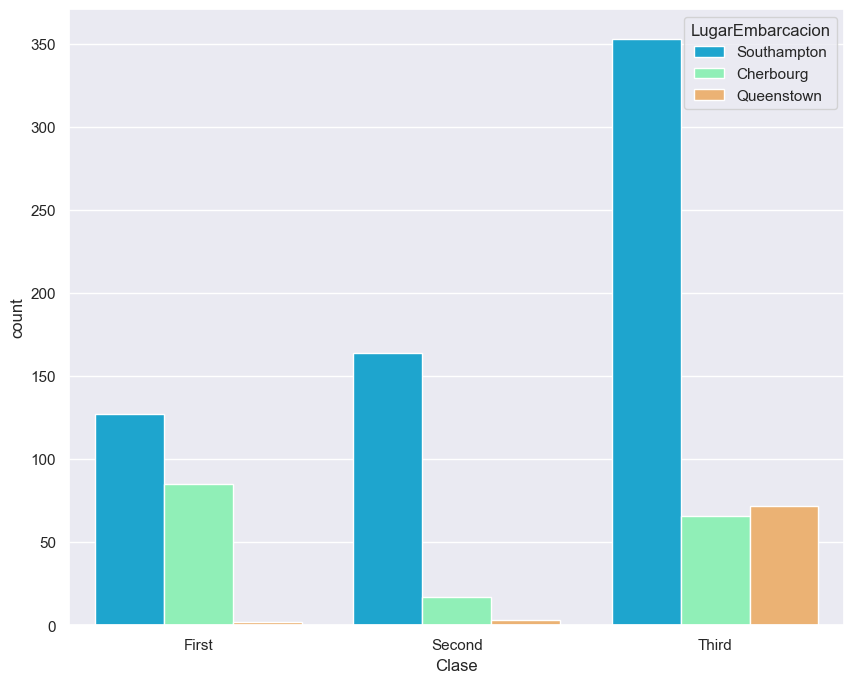

In [16]:
# Grafico para variables categóricas
sns.countplot(x="Clase",data=df,hue='LugarEmbarcacion', palette='rainbow')

<Axes: xlabel='Tarifa', ylabel='Edad'>

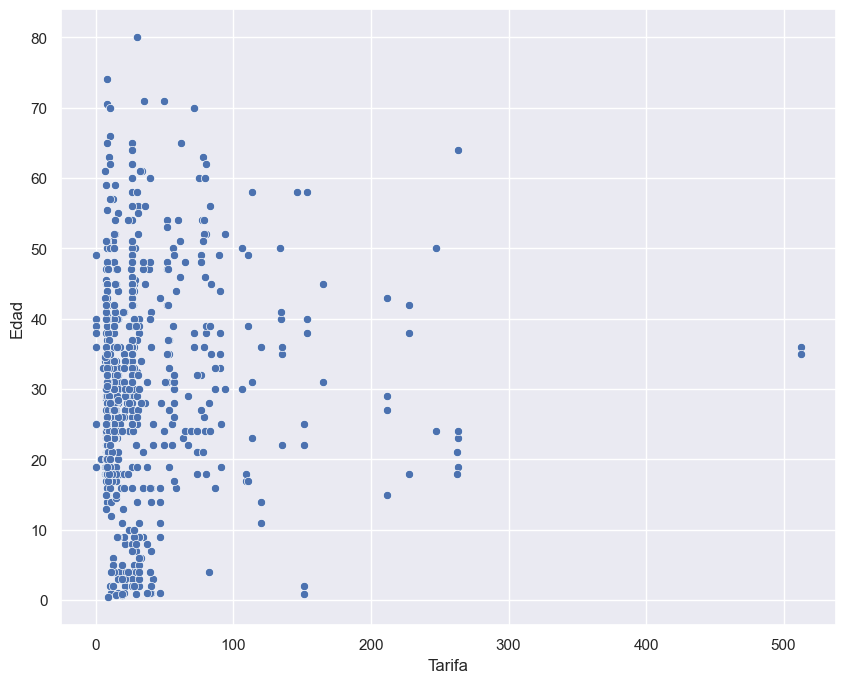

In [17]:
sns.scatterplot(data=df, x= 'Tarifa', y= 'Edad')

<Axes: xlabel='Tarifa', ylabel='Edad'>

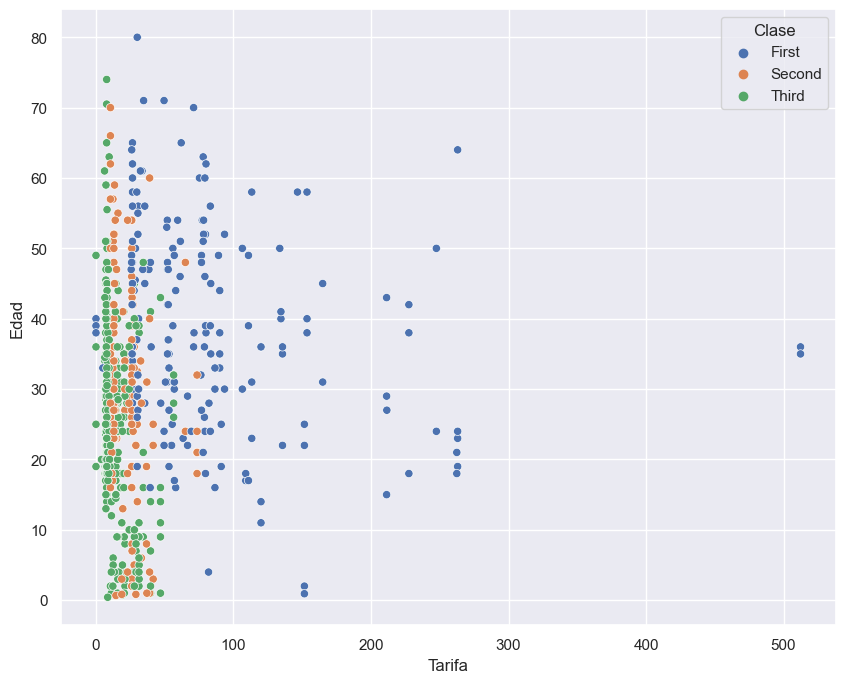

In [18]:
sns.scatterplot(data=df, x= 'Tarifa', y= 'Edad', hue='Clase')

<Axes: xlabel='LugarEmbarcacion', ylabel='count'>

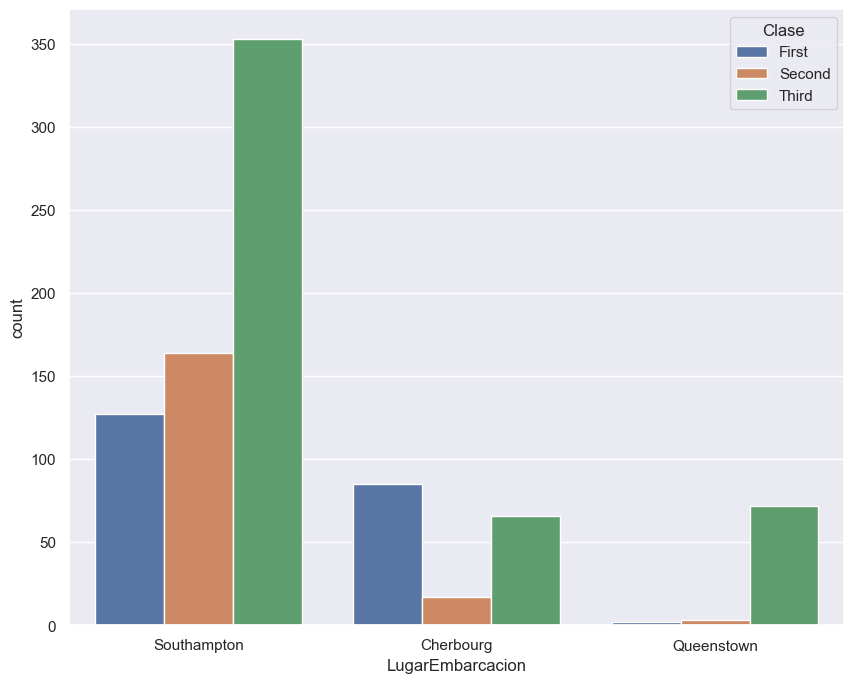

In [19]:
sns.countplot(data=df, x="LugarEmbarcacion", hue="Clase")

<Axes: xlabel='Tarifa', ylabel='LugarEmbarcacion'>

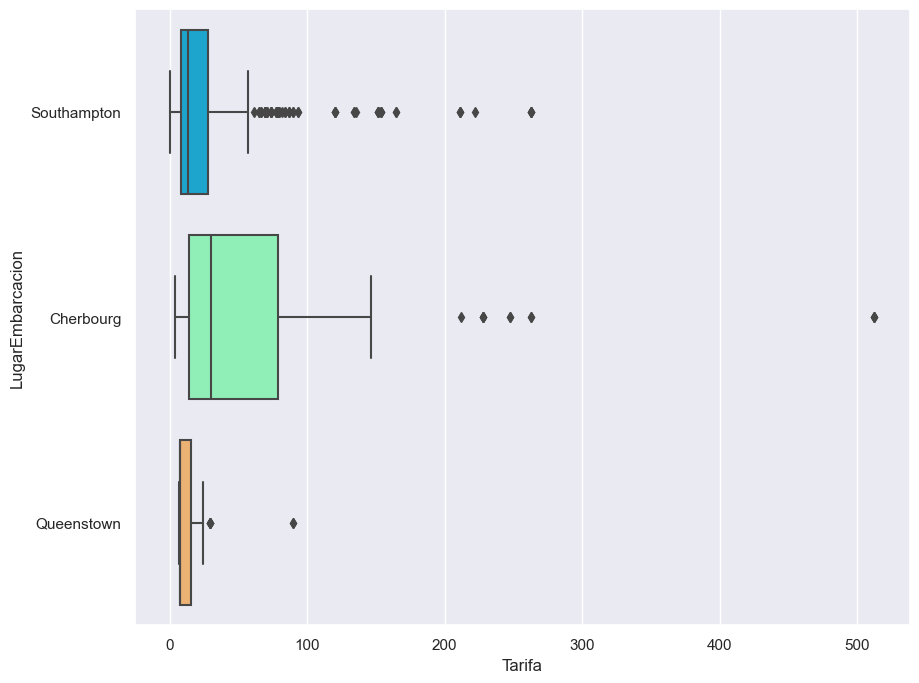

In [20]:
sns.boxplot(x='Tarifa',y='LugarEmbarcacion',data=df, palette='rainbow')

<Axes: xlabel='Sexo', ylabel='Edad'>

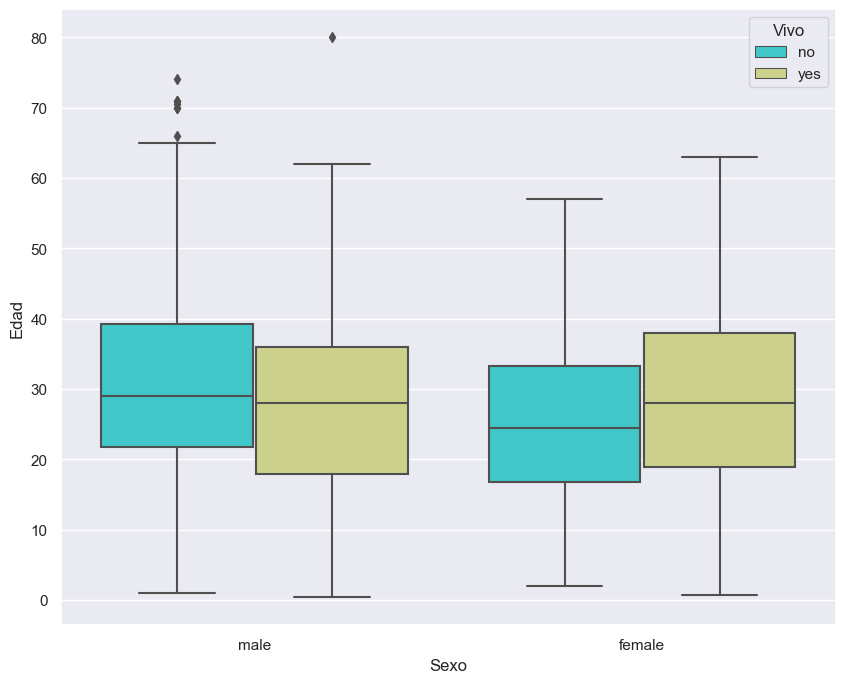

In [21]:
sns.boxplot(x='Sexo',y='Edad',data=df, palette='rainbow', hue='Vivo')

In [22]:
df_Number = df.select_dtypes(include='number')
dataCorr = df_Number.corr()
dataCorr

,Sobreviviente,ClasePasaje,Edad,HnsEsposo,PadresHijos,Tarifa
Sobreviviente,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
ClasePasaje,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Edad,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
HnsEsposo,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
PadresHijos,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Tarifa,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

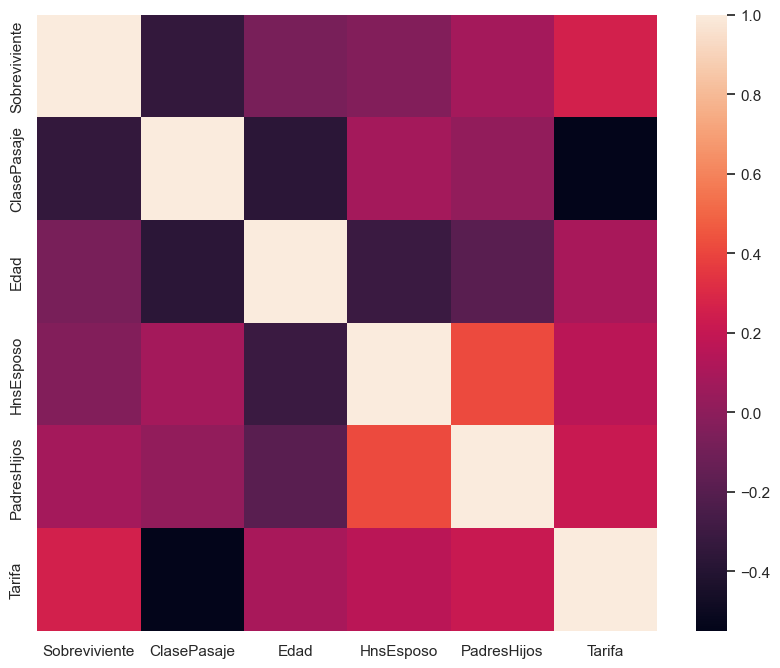

In [23]:
sns.heatmap(df_Number.corr())

<Axes: >

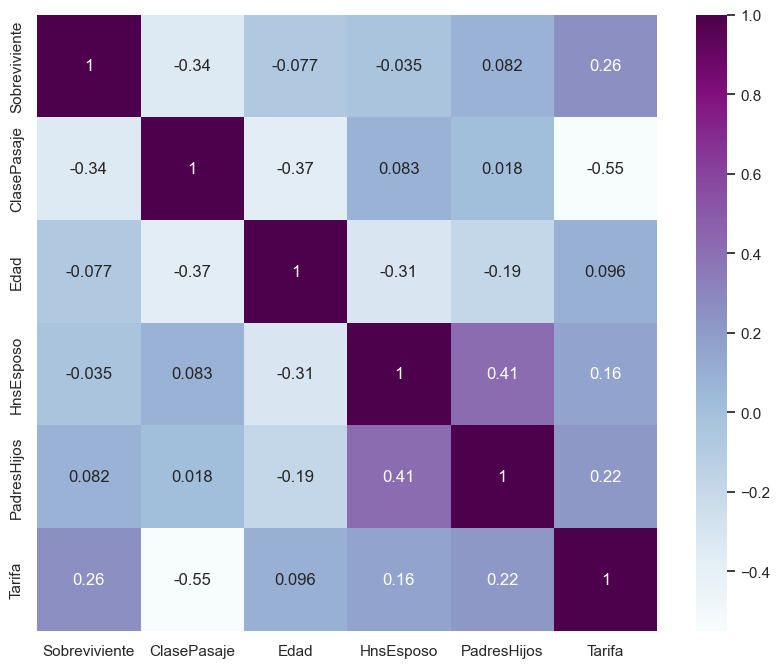

In [24]:
sns.heatmap(df_Number.corr(),annot=True, cmap = "BuPu")